In [27]:
import os
import time
import glob
import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.table import Table
from astropy.coordinates import SkyCoord
import yaml

import importlib
import numpy as np
import pandas as pd
from math import floor

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

from scipy.optimize import minimize

In [28]:
import sys
sys.path.append('observing-program/py')
sys.path.append('grism_sim/py')
os.environ['github_dir']='.'
import grism_dispersion
import footprintutils as fp
import roman_coords_transform as ctrans
from chi2_func import chi2J_vec, chi2L_vec
import optical_model

code_data_dir = 'observing-program/data/'
rctrans = ctrans.RomanCoordsTransform(file_path=code_data_dir)

In [29]:
optmod = optical_model.RomanOpticalModel()

In [30]:
ra0 = 0
dec0 = 0
dithstep = 0.125*.2,0.125*.4
ndith = 2
decpa = 0.087
rapa = 0.0
decoffl = [decpa,decpa,-decpa,-decpa]
raoffl = [rapa,rapa/3,-rapa/3,-rapa]
pa_off = 10
pal = [-2.5+pa_off,2.5+pa_off,177.5+pa_off,182.5+pa_off]
pa = pal[0]
decoff = decoffl[0]#decpa/2
raoff = raoffl[0]

pointing_coords = []

survey = 0

if survey == 0:
    pointing_coords.append([ra0+raoff, dec0+decoff, pa])
elif survey == 1:
    for dith in range(0,ndith):
        decoff = decoffl[0]#decpa/2
        raoff = raoffl[0]
        pointing_coords.append([ra0+raoff+dith*dithstep[0], dec0+decoff+dith*dithstep[1], pa])

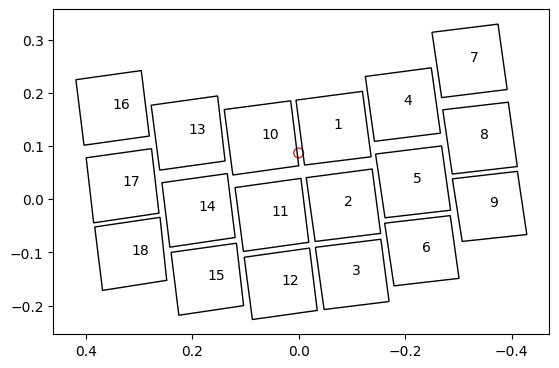

In [31]:
footprints = {}

for i in range(len(pointing_coords)):
  dfoot = rctrans.wfi_sky_pointing(pointing_coords[i][0], pointing_coords[i][1], pointing_coords[i][2], ds9=False, ax=None)
  for detector in range(1,19):
    footprints[detector+i*18] = dfoot[0][detector]

In [32]:
def square_to_quad_transform(x, y, dest_corners, src_size=4088):
    """
    Transform (x, y) coordinates from a square [0, src_size] to a quadrilateral defined by dest_corners.
    """
    # Source square corners
    src = np.array([
        [0, 0],
        [src_size, 0],
        [src_size, src_size],
        [0, src_size]
    ], dtype=np.float64)
    dst = np.roll(dest_corners, -1, axis=0)  # Ensure corners are in order

    # Build the system of equations for homography
    A = []
    for (x_src, y_src), (x_dst, y_dst) in zip(src, dst):
        A.append([x_src, y_src, 1, 0, 0, 0, -x_dst*x_src, -x_dst*y_src])
        A.append([0, 0, 0, x_src, y_src, 1, -y_dst*x_src, -y_dst*y_src])
    A = np.array(A)
    b = dst.flatten()
    # Solve for homography matrix elements
    h, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    H = np.append(h, 1).reshape(3, 3)

    # Prepare input points
    pts = np.vstack([x, y, np.ones_like(x)])
    pts_new = H @ pts
    pts_new /= pts_new[2]
    return pts_new[0], pts_new[1]

def quad_to_square_transform(x, y, src_corners, src_size=4088):
    """
    Transform (x, y) coordinates from a quadrilateral defined by src_corners
    back to a square [0, src_size] x [0, src_size].
    """
    x = np.asarray(x)
    y = np.asarray(y)
    dst = np.array([
        [0, 0],
        [src_size, 0],
        [src_size, src_size],
        [0, src_size]
    ], dtype=np.float64)
    src = np.array(src_corners, dtype=np.float64)
    src = np.roll(src, -1, axis=0)

    # Build system for homography (from quad to square)
    A = np.zeros((8, 8))
    b = np.zeros(8)
    for i in range(4):
        x_src, y_src = src[i]
        x_dst, y_dst = dst[i]
        A[2*i]   = [x_src, y_src, 1, 0, 0, 0, -x_dst*x_src, -x_dst*y_src]
        A[2*i+1] = [0, 0, 0, x_src, y_src, 1, -y_dst*x_src, -y_dst*y_src]
        b[2*i]   = x_dst
        b[2*i+1] = y_dst
    h = np.linalg.solve(A, b)
    H = np.append(h, 1).reshape(3, 3)

    pts = np.vstack((x, y, np.ones_like(x)))
    pts_new = H @ pts
    pts_new[:2] /= pts_new[2]
    return pts_new[0], pts_new[1]

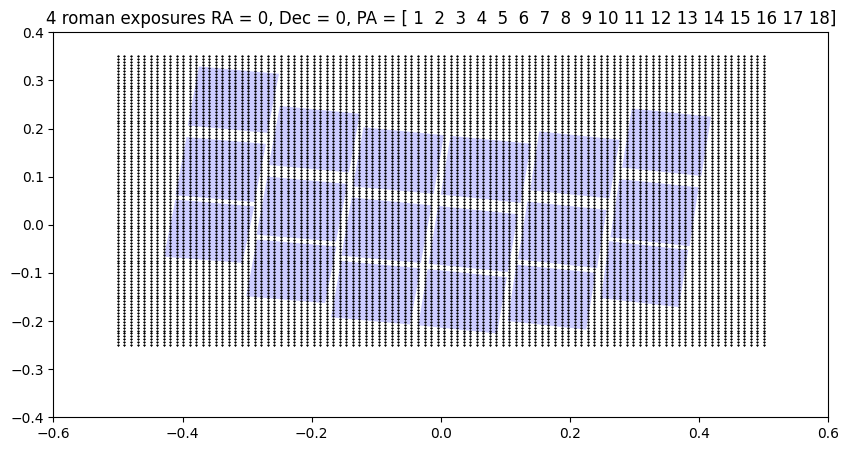

In [33]:
fig, ax = plt.subplots(figsize = (10,5))

##sim parameters
ns = 10000 # initial number of stars
exp = np.arange(len(footprints))+1
Nexp = len(exp)

for footprint in exp:
  data = footprints[footprint]
  corners = data['vertices']
  polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')
  
  ax.add_patch(polygon)

plt.title("4 roman exposures RA = 0, Dec = 0, PA = {}".format(exp))

# stars_x = (np.random.rand(ns) - 0.5)*1
# stars_y = (np.random.rand(ns) - 0.5)*0.7

stars_x = np.linspace(-0.5,0.5, 100)
stars_x = np.tile(stars_x, 100)
stars_y = np.linspace(-0.25,0.35,100)
stars_y = np.sort(np.repeat(stars_y, 100))

plt.xlim(-0.6, 0.6)
plt.ylim(-0.4, 0.4)

plt.plot(stars_x, stars_y, "*", color = "black", markersize = 1)
# plt.gca().invert_xaxis()
# plt.plot(star[0], star[1], "*", color = "black", markersize = 3)
plt.show()

In [34]:
#create lists of paths for exposures

stars = np.zeros((ns,2))
stars[:,0] = stars_x
stars[:,1] = stars_y

select_exposure = {}

for footprint in exp:
  corners = footprints[footprint]['vertices']
  verts = np.concatenate((corners, [corners[0]]))
  path = Path(verts)
  footprints[footprint]['path'] = path
  ondetector = path.contains_points(stars)
  select_exposure[footprint] = ondetector



In [35]:
def bin_cut(beam):
    wv = beam["trace_wvl"][0]
    xb = beam["trace_pix_x"][0]
    yb = beam["trace_pix_y"][0]
    
    bins = np.linspace(np.min(wv), np.max(wv), 23)
    bins = bins[:-1]
    bin_ind = np.digitize(wv, bins)

    bin_x = np.round(np.array([np.mean(xb[bin_ind == i]) for i in range(1, len(bins)+1)]), decimals = 0)
    bin_y = np.round(np.array([np.mean(yb[bin_ind == i]) for i in range(1, len(bins)+1)]), decimals = 0)
    colors = np.linspace(0, 1, len(bin_x))
    select_on_detector = (bin_x >= 0) & (bin_x <= 4088) & (bin_y >= 0) & (bin_y <= 4088)
    bin_x = bin_x[select_on_detector]   
    bin_y = bin_y[select_on_detector]
    cut_colors = colors[select_on_detector]
    cut_bins = bins[select_on_detector]
    return bin_x, bin_y, cut_colors, select_on_detector, cut_bins


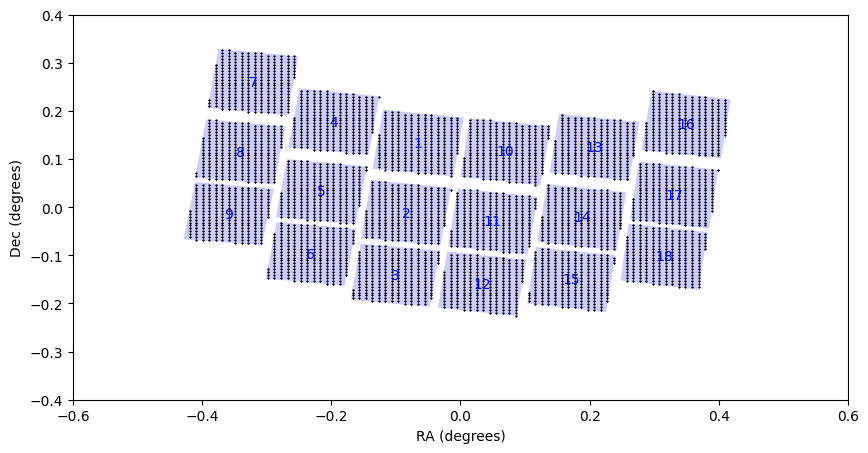

In [36]:
select_observed = np.array([False]*ns)
for footprint in exp:
  select_observed += select_exposure[footprint]
ns_obs = np.sum(select_observed)
stars_obs = stars[select_observed]

select_obs_exposure = {}
for footprint in exp:
  select_obs_exposure[footprint] = select_exposure[footprint][select_observed]

# Create a figure and an axes
fig, ax = plt.subplots(figsize = (10,5))
for footprint in exp:
  corners = footprints[footprint]['vertices']
  polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')
  ax.add_patch(polygon)
  # Add the footprint label at the centroid of the polygon
  centroid = np.mean(corners, axis=0)
  ax.text(centroid[0], centroid[1], str(footprint), color='blue', fontsize=10, ha='center', va='center')

plt.plot(stars_obs[:,0], stars_obs[:,1], "*", color = "black", markersize = 1)
plt.xlim(-0.6, 0.6)
plt.ylim(-0.4, 0.4)
# Display the plot
plt.xlabel('RA (degrees)')
plt.ylabel('Dec (degrees)')
plt.show()

In [37]:
#im gonna assume an arbitrary sigma k here
np.random.seed(17)
sigk = 0.1
sig_star = 0.5
true_k = np.random.normal(0,sigk**2,len(exp))
true_brightness = np.random.normal(1.0,sig_star**2,len(stars_obs))
sig_ij = 0.01
sig_lam = 0.1

true_k -= np.mean(true_k)
Nstars  = stars_obs.shape[0] #observed number of stars


# exists_in_exp[i, j] is True if star j is observed in any detector of exp[i].
exists_in_exp = np.zeros((Nexp, Nstars), dtype=bool)

for i in exp:
    mask = np.zeros(Nstars, dtype=bool) #initialise all false
        #loop through every detector (theres probably a faster way to do this)
        #do path contains points for each exposure
    path = footprints[i]['path']
    mask |= path.contains_points(stars_obs)      
    exists_in_exp[i-1] = mask

    
# now for a row i, you have a mask to select stars that are observed by it
# and for a column j, you have a mask that selects exposures that contain star j
# this is a useful mask to generate m_ij


In [41]:
_coeff = optmod._get_beam_trace(2044,2044,1, width=1, order="+1")

_1, _2, _3, _4, master_bins = bin_cut(_coeff) #left edges of bins

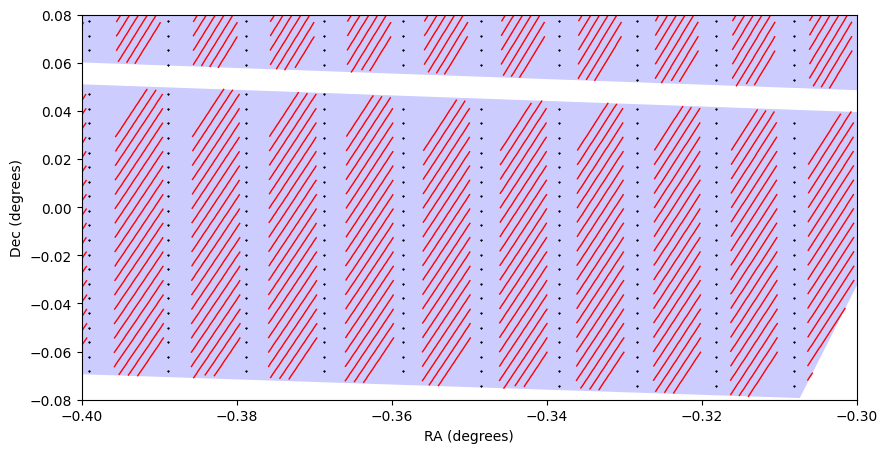

In [42]:
fig, ax = plt.subplots(figsize = (10,5))
for footprint in exp:
    corners = footprints[footprint]['vertices']
    polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')
    ax.add_patch(polygon)
    # Add the footprint label at the centroid of the polygon
    centroid = np.mean(corners, axis=0)
    # ax.text(centroid[0], centroid[1], str(footprint), color='black', fontsize=10, ha='center', va='center')

plt.plot(stars_obs[:,0], stars_obs[:,1], "*", color = "black", markersize = 1)
# plt.xlim(-0.6, 0.6)
# plt.ylim(-0.3, 0.4)

plt.xlim(-0.45, -0.30)
plt.ylim(-0.08, 0.08)

"""apply grism information to stars"""

wvl_bins = len(master_bins)
stars_wvl = {key: val for key, val in zip(master_bins, [[] for _ in range(wvl_bins)])}

star_colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'cyan']

for i in range(len(exp)):
    star_mask = exists_in_exp[i]
    stars_in_exp = stars_obs[star_mask]
    for star in stars_in_exp:
        fid = i + 1
        det_coord = quad_to_square_transform(star[0], star[1], footprints[fid]['vertices'], src_size=4088)
        det_pixl = np.floor(det_coord)
        coeff = optmod._get_beam_trace(det_pixl[0], det_pixl[1], fid, width=1, order="+1")
        x_binned, y_binned, colors, select_on_detector, bins = bin_cut(coeff)
        px, py = square_to_quad_transform(x_binned, y_binned, footprints[fid]['vertices'], src_size=4088)
        
        temp_dict = {key: val for key, val in [(bin, coord) for bin, coord in zip(bins, np.array([px,py]).T)]}
        plt.plot(px,py, color="red", lw = 1)
        for b,x,y in zip(bins, px, py):
            stars_wvl[b].append((x, y))

for b in stars_wvl.keys():
    stars_wvl[b] = np.array(stars_wvl[b])

plt.xlim(-0.4, -0.30)
plt.ylim(-0.08, 0.08)

# plt.gca().invert_yaxis()
# Display the plot
plt.xlabel('RA (degrees)')
plt.ylabel('Dec (degrees)')
plt.show()

[0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4  1.45 1.5  1.55]
[0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4  1.45 1.5  1.55
 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95]
[0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4  1.45 1.5  1.55
 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95]
[0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4  1.45 1.5  1.55
 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95]
[0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4  1.45 1.5  1.55
 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95]
[0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4  1.45 1.5  1.55
 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95]
[0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4  1.45 1.5  1.55
 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95]
[0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4  1.45 1.5  1.55
 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95]
[1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4  1.45 1.5  1.55 1.6  1.65
 1.7  1.75 1.8  1.85 1.9  1.95]
[1.45 1.5  1.55 1.6  1.65 1.7  1.7

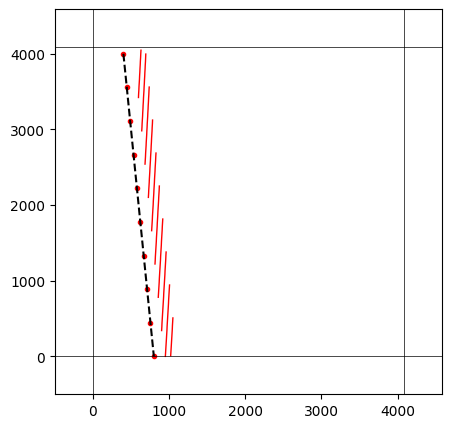

In [45]:
fig, ax = plt.subplots(figsize = (5,5))
xt = np.linspace(400,800,10)
yt = -10*(xt-500)+3000

tester = np.zeros((10,2))
tester[:,0] = xt
tester[:,1] = yt
for det_pixl in tester:
    fid = 8 + 1
    coeff = optmod._get_beam_trace(det_pixl[0], det_pixl[1], fid, width=1, order="+1")
    x_binned, y_binned, colors, select_on_detector, bins = bin_cut(coeff)
    print(bins)
    px, py = square_to_quad_transform(x_binned, y_binned, footprints[fid]['vertices'], src_size=4088)
    plt.plot(det_pixl[0], det_pixl[1], "ro", markersize = 3, label="trace center")
    plt.plot(x_binned,y_binned, color="red", lw = 1)


plt.plot(xt, yt, "k--", label="test line")
plt.xlim(-500, 4588)
plt.ylim(-500, 4588)
plt.axvline(0, color='black', lw=0.5)
plt.axhline(0, color='black', lw=0.5)   
plt.axhline(4088, color='black', lw=0.5)
plt.axvline(4088, color='black', lw=0.5)
plt.show()

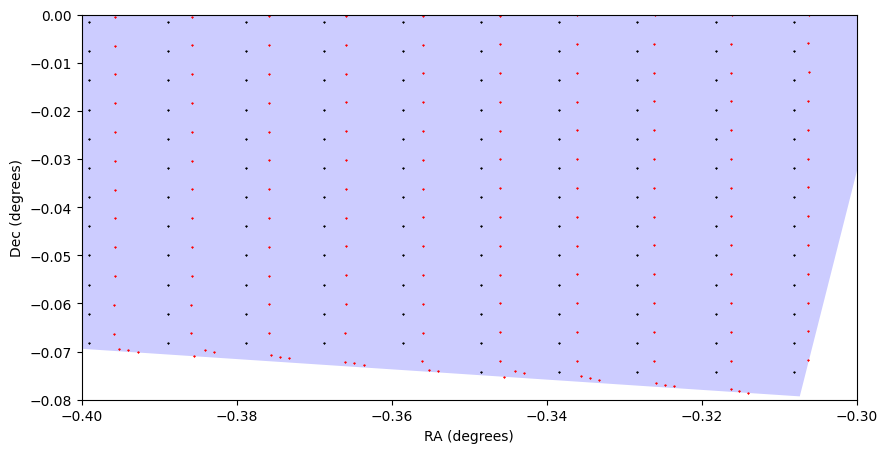

In [ ]:
fig, ax = plt.subplots(figsize = (10,5))
for footprint in exp:
    corners = footprints[footprint]['vertices']
    polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')
    ax.add_patch(polygon)
    # Add the footprint label at the centroid of the polygon
    centroid = np.mean(corners, axis=0)
    # ax.text(centroid[0], centroid[1], str(footprint), color='black', fontsize=10, ha='center', va='center')

plt.plot(stars_obs[:,0], stars_obs[:,1], "*", color = "black", markersize = 1)
# plt.xlim(-0.6, 0.6)
# plt.ylim(-0.3, 0.0)

plt.xlim(-0.4, -0.30)
plt.ylim(-0.08, 0)

plt.plot(stars_wvl[0.9][:,0], stars_wvl[0.9][:,1], "*", color = "red", markersize = 1)
# Display the plot
plt.xlabel('RA (degrees)')
plt.ylabel('Dec (degrees)')
plt.show()

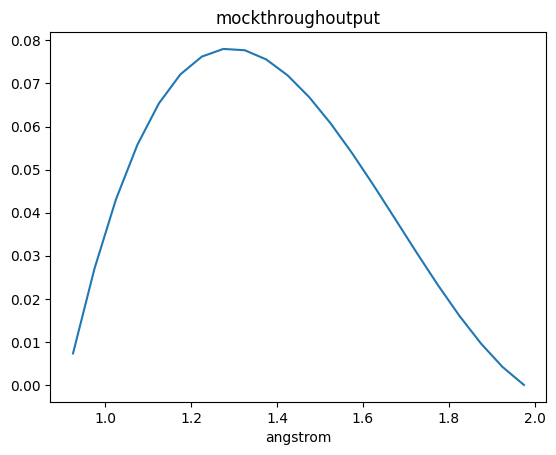

[0.925 0.975 1.025 1.075 1.125 1.175 1.225 1.275 1.325 1.375 1.425 1.475
 1.525 1.575 1.625 1.675 1.725 1.775 1.825 1.875 1.925 1.975]


In [ ]:
def throughput(x):
    coeff = [0.4, -0.9, -2.7, 3.3]
    scale = 1
    terms = [coeff[i]*x**(3-i) for i in range(4)]
    return scale*sum(terms)

lam = np.linspace(-2.5,2,22)
rescaled = (throughput(lam)-np.min(throughput(lam))) / np.sum((throughput(lam)-np.min(throughput(lam))))
master_bin_centers = (master_bins[1] - master_bins[0])/2 + master_bins
plt.plot(master_bin_centers, rescaled)
plt.title("mockthroughoutput")
plt.xlabel("angstrom")
plt.show()
print(master_bin_centers)

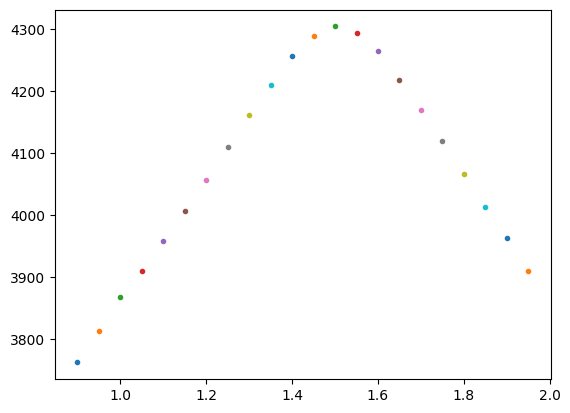

In [44]:
for b in stars_wvl.keys():
    plt.plot(b, len(stars_wvl[b]), ".")

In [ ]:
m_ij = [true_brightness for _ in range(Nexp)]
m_ij = np.array(m_ij)
m_ij = np.where(exists_in_exp, true_brightness - true_k[:,None], 0.0)

m_lamij = rescaled[:, None, None] * m_ij[None, :, :]
# mask = (m_lamij != 0)
# error_array = np.random.normal(0,0.005,size = m_lamij.shape)
# error_array *= mask
# m_lamij += error_array


# 0: wavelength
# 1: exposure
# 2: star

In [ ]:
# For each star j, collect the list of exposures containing it 
# in_exp is a list of length Nstars, each element a list of exposures (differing lengths!)
in_exp = [
    [exp[i] for i in np.nonzero(exists_in_exp[:, j])[0]]
    for j in range(Nstars)
]

# Find unique overlap patterns using set, and discard those of length 1 (can't use stars that are only observed once)
unique_patterns = {
    tuple(lst) for lst in in_exp
    if len(lst) > 1
}
overlaps = [list(pat) for pat in unique_patterns]


# For each overlap pattern, build a boolean mask (length Nstars)
# that is True exactly where in_detector[j] == that pattern.
select_overlaps = []
for pat in overlaps:
    # build a boolean array of shape (Nexp,) marking which exposures are in this pattern
    pat_mask = np.isin(exp, pat)
    # compare full exists_in_exp against this mask column-wise, so for each star, if the pattern in exists_in_exp matches True, else False
    star_mask = np.all(exists_in_exp == pat_mask[:, None], axis=0)
    # so for e
    # print(star_mask.shape)
    select_overlaps.append(star_mask)

# select_overlaps[l][j] is true if star j belongs to overlap l
# shape (Nl, Nstars)


In [ ]:
select_overlaps = np.array(select_overlaps)
select_overlaps.shape

(0,)

In [ ]:
Nl = len(overlaps)
Nstarl = np.array([len(stars_obs[select_overlaps[l]]) for l in range(Nl)])

m_il = np.zeros((len(exp), Nl))#this could probably be optimised like m_ij
for i in range(len(exp)):
  for l in range(Nl):
    m_il[i,l] = np.mean(m_ij[i,:][select_overlaps[l]])

# m_il[i,l] is the mean brightness of stars in exposure i that are also in overlap l
# m_il is now a 2D array with shape (Nexp, Nl)

# generate m_lamil from m_lamij

m_lamil = np.zeros((len(lam), len(exp), Nl))  # shape (Nlam, Nexp, Nl)
for l in range(Nl):
    for i in range(len(exp)):
        m_lamil[:, i, l] = np.mean(m_lamij[:, i, :][:, select_overlaps[l]], axis=1)

# m_lamil is now a 3D array with shape (Nlam, Nexp, Nl)

In [ ]:
k_test = np.zeros(len(exp))

start = time.time()
resL_vec = minimize(chi2L_vec, k_test, method='L-BFGS-B', args=(m_il, sig_ij/np.sqrt(Nstarl), sigk), jac = True)
print(time.time() - start)

start = time.time()
resJ_vec = minimize(chi2J_vec, k_test, method='L-BFGS-B', args=(m_ij, sig_ij, sigk), jac = True)
print(time.time() - start)


0.0004999637603759766
0.0009999275207519531


C:\Users\alanb\AppData\Local\Temp\ipykernel_37652\602827349.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.plot((true_k/resJ_vec.x))
C:\Users\alanb\AppData\Local\Temp\ipykernel_37652\602827349.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(true_k/resL_vec.x, "--")


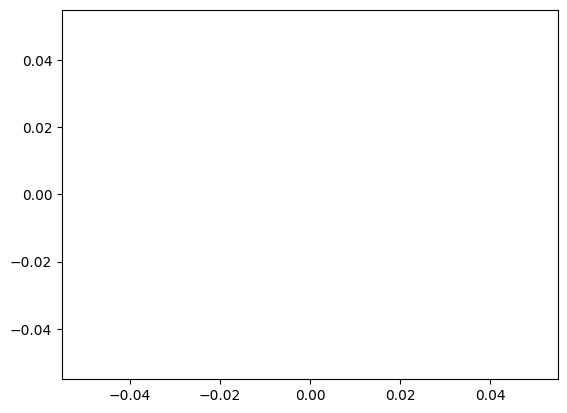

In [ ]:

plt.plot((true_k/resJ_vec.x))
plt.plot(true_k/resL_vec.x, "--")
plt.show();

C:\Users\alanb\AppData\Local\Temp\ipykernel_37652\1518580089.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.hist(true_k/resJ_vec.x, bins = 30, alpha=0.5, label='J method')


ValueError: supplied range of [-inf, inf] is not finite

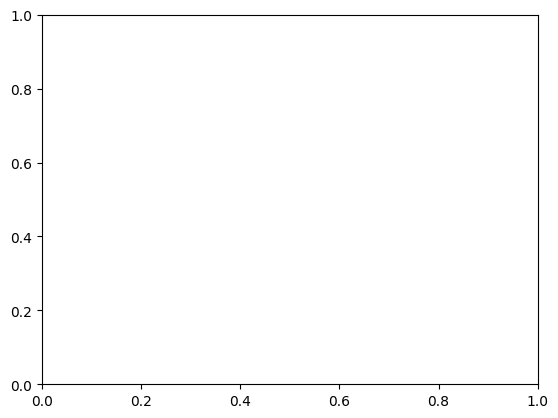

In [ ]:
plt.hist(true_k/resJ_vec.x, bins = 30, alpha=0.5, label='J method')
plt.show();